In [10]:
from readers import gxs_utils as gxs
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

In [6]:
today_date_str = datetime.now().strftime("%Y_%m_%d")

In [7]:
gxs_filepath = "data/gxs_sim/Tb_gxs2402bae_g26_d20190922_t211500_e211500.nc"

ds = gxs.open_gxs_data(gxs_filepath)

Plotting Cloudy Brightness Temperature:


Channel index 240: Frequency of 2178.28 cm-1 (4.59 um)


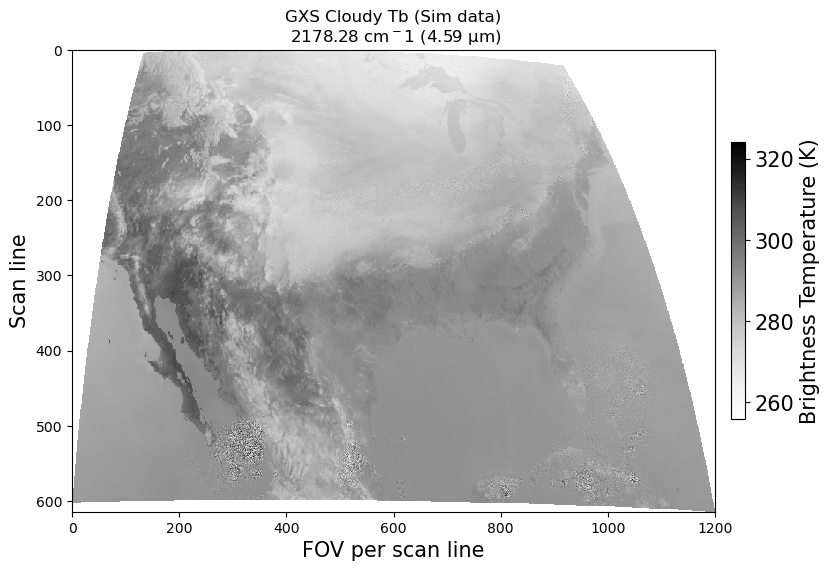

In [9]:
'''
Plotting Cloudy Brightness Temperature. 

:param channel_index: between 0 and 2402
:param freq: between 2252.26 and 680.09 cm-1
:param ds: from open_gxs_data()
'''
channel_index = 240

freq = ds['freq'][channel_index].values.item()
print(f"Channel index {channel_index}: Frequency of {round(freq,2)} cm-1 ({round(10_000/freq, 2)} um)")

img = ds['Tb_CLR'][channel_index, :, :]
img = img.where(img != -19998) #--- Missing values to NaNs

x = img['num_fov_per_scan_line'].values
y = img['num_scan_line'].values
z = img.values

fig, ax = plt.subplots(figsize=(10, 6))

pcm = ax.pcolormesh(
    x, y, z,
    cmap='Greys',
    shading='nearest'
)

clb = fig.colorbar(pcm, shrink=0.6, pad=0.02, ax=ax)
clb.set_label('Brightness Temperature (K)', fontsize=15)
clb.ax.tick_params(labelsize=15)
ax.invert_yaxis()

ax.set_xlabel('FOV per scan line', fontsize=15)
ax.set_ylabel('Scan line', fontsize=15)
ax.set_title(f'GXS Cloudy Tb (Sim data)\n {round(freq,2)} cm$^{-1}$ ({round(10_000/freq, 2)} µm)')

plt.savefig(f"plots/{today_date_str}_gxs_sim.png", dpi=200, bbox_inches='tight')
plt.show()

Plot GXS sim block: 

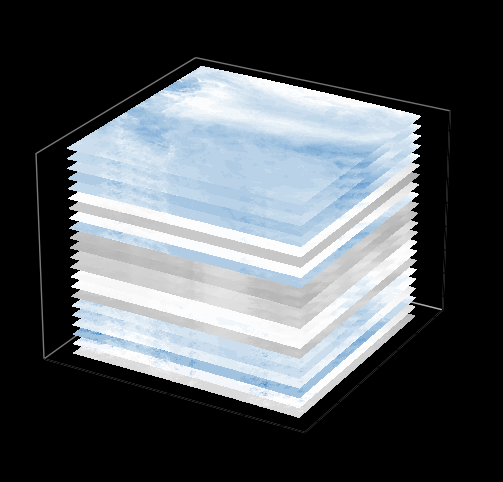

In [11]:
import matplotlib.colors as mcolors

channel_list = range(100, 2201, 100)

img_3d = ds['Tb_CLR'].sel(number_channels=channel_list)

# Remove NaN values
img_3d = img_3d.where(img_3d != -19998)

# Crop to a square
ny = img_3d.sizes['num_scan_line']
nx = img_3d.sizes['num_fov_per_scan_line']
side = min(nx, ny)
x0 = (nx - side) // 2
y0 = (ny - side) // 2

img_3d = img_3d.isel(
    num_fov_per_scan_line=slice(x0, x0 + side),
    num_scan_line=slice(y0, y0 + side)
)

# Get the coordinates
x = img_3d['num_fov_per_scan_line'].values
y = img_3d['num_scan_line'].values

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(8, 6), facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black')

# Optional: make background clean
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(False)

# Consistent color scaling
finite_vals = img_3d.values[np.isfinite(img_3d.values)]
vmin = finite_vals.min() # Adjustment to get colors to line up nicely
vmax = finite_vals.max()
cmap = mcolors.LinearSegmentedColormap.from_list(
            "custom_cmap",
            [(0, "#A9A9A9"), (0.5, "white"), (1, "#1167b1")]
        )
norm = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)

# Plot stacked slices
for img, ch in zip(img_3d, channel_list):
    img_np = img.values

    ax.contourf(
        X, Y, img_np,
        levels=20,
        zdir='z',
        offset=ch,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

# Axes labeling & limits
ax.set_xlabel('FOV per scan line')
ax.set_ylabel('Scan line')
ax.set_zlabel('ABI Channel', color="black")

ax.invert_yaxis()
ax.set_zlim(np.min(channel_list), np.max(channel_list))

# Viewing angle
ax.view_init(elev=25, azim=-60)

plt.savefig(f"plots/{today_date_str}_gxs_sim_stack.png", dpi=200, bbox_inches='tight')
plt.show()